### Bibliotecas

In [26]:
# Manipular dados
import pandas as pd
import numpy as np

# Configurações
import warnings
import os

# Visualização
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error

from scipy.stats import randint, uniform

from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance

In [27]:
# Definir diretóri0
os.chdir('G:/Meu Drive/MeuDrive2/academico/3.kaggle/7.Predicting_Road_Accident_Risk')

# Exibir todas as linhas e colunas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_columns', None)

# Evitar avisos
warnings.filterwarnings('ignore')

### Importação, manipulação e análise dos daods

In [28]:
# Importar os dados de treino
train = pd.read_csv('train.csv')

# Importar dados de teste
test = pd.read_csv('test.csv')

# Importar dados de submissão
sample_submission = pd.read_csv('sample_submission.csv')

In [29]:
# Primeiras observações do conjunto de treino
train.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [30]:
# Remover a coluna id, ela é desnecessária nos dados de treino
train = train.drop(columns=["id"])

In [31]:
# Dimensão do df
train.shape

(517754, 13)

In [32]:
# Verificar se há dados faltantes
train.isna().sum().sort_values(ascending=False)

road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [33]:
# Resumo do df de treino
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517754 non-null  object 
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   lighting                517754 non-null  object 
 5   weather                 517754 non-null  object 
 6   road_signs_present      517754 non-null  bool   
 7   public_road             517754 non-null  bool   
 8   time_of_day             517754 non-null  object 
 9   holiday                 517754 non-null  bool   
 10  school_season           517754 non-null  bool   
 11  num_reported_accidents  517754 non-null  int64  
 12  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 37.5+ MB


In [34]:
# Estatisticas descritivas das variáveis numéricas
train.describe().T

,count,mean,std,min,25%,50%,75%,max
num_lanes,517754.0,2.491511,1.120434,1.0,1.00,2.00,3.00,4.0
curvature,517754.0,0.488719,0.272563,0.0,0.26,0.51,0.71,1.0
speed_limit,517754.0,46.112575,15.788521,25.0,35.00,45.00,60.00,70.0
num_reported_accidents,517754.0,1.187970,0.895961,0.0,1.00,1.00,2.00,7.0
accident_risk,517754.0,0.352377,0.166417,0.0,0.23,0.34,0.46,1.0


In [35]:
# Exibir o nome dos atributos numéricos
num_cols = train.select_dtypes(include='number').columns
print(num_cols)

Index(['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents',
       'accident_risk'],
      dtype='object')


### Separar em treino e teste

In [36]:
# Separando os dados
from sklearn.model_selection import train_test_split

target = "accident_risk"
X = train.drop(columns=[target])
y = train[target]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, # Conjunto de validação
                                                      random_state=42, 
                                                      shuffle=True)

### Encoding

In [37]:
# Primeiras observações
X_train.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
143159,rural,2,0.43,60,dim,clear,False,False,afternoon,True,True,2
20172,highway,4,0.18,25,night,clear,False,False,afternoon,True,False,1
57926,urban,1,0.20,70,night,clear,False,True,morning,True,True,1
193319,urban,3,0.81,60,daylight,foggy,True,False,evening,True,True,1
213938,rural,3,0.43,35,night,rainy,False,True,morning,True,True,2


In [38]:
# Fazer ordinal encoding para road_type, lighting, weather, time_of_day
from sklearn.preprocessing import OrdinalEncoder

# Colunas a codificar
cat_cols = ['road_type', 'lighting', 'weather', 'time_of_day']

encoder = OrdinalEncoder()

# Ajustar apenas no treino
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])

# Aplicar ao conjunto de validação
X_valid[cat_cols] = encoder.transform(X_valid[cat_cols])

In [39]:
# Transformar de booleanas para 0/1
bool_cols = ['road_signs_present', 'public_road', 'holiday', 'school_season']

# Converter True/False para 1/0
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_valid[bool_cols] = X_valid[bool_cols].astype(int)

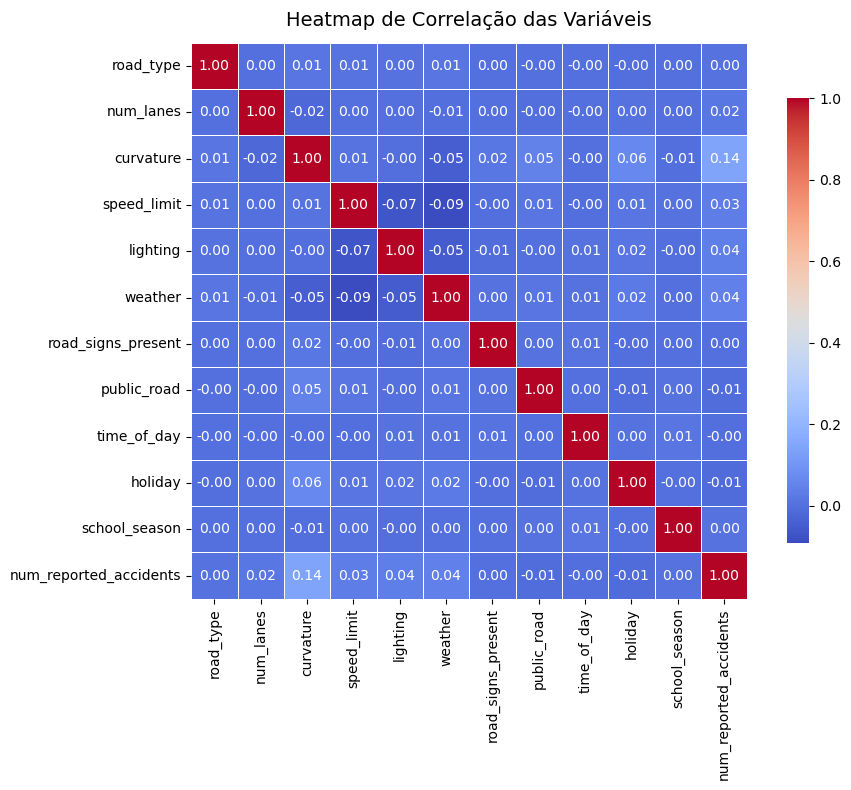

In [40]:
# Calcular matriz de correlação
corr = X_train.corr(numeric_only=True)

# Plotar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8},
    linewidths=0.5
)

plt.title("Heatmap de Correlação das Variáveis", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

### Padronizar os dados

In [41]:
from sklearn.preprocessing import MinMaxScaler

# Criar o scaler
scaler = MinMaxScaler()

# Ajustar apenas no treino e transformar
X_train_scaled = scaler.fit_transform(X_train)

# Aplicar a mesma transformação no conjunto de validação
X_valid_scaled = scaler.transform(X_valid)

# Transformar de volta em DataFrame mantendo os nomes das colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_valid_scaled = pd.DataFrame(X_valid_scaled, columns=X_valid.columns)

In [42]:
# Df de treino final
X_train_scaled.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,0.5,0.333333,0.43,0.777778,0.5,0.0,0.0,0.0,0.0,1.0,1.0,0.285714
1,0.0,1.000000,0.18,0.000000,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.142857
2,1.0,0.000000,0.20,1.000000,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.142857
3,1.0,0.666667,0.81,0.777778,0.0,0.5,1.0,0.0,0.5,1.0,1.0,0.142857
4,0.5,0.666667,0.43,0.222222,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.285714


In [43]:
# Remover a variável 'school_season' após a padronização
X_train_scaled = X_train_scaled.drop(columns=['school_season'])
X_valid_scaled = X_valid_scaled.drop(columns=['school_season'])

### Previsão

#### XGBoost - RandomSearch

In [44]:
# Modelo base
xgb = XGBRegressor(
    random_state=42,
    tree_method="hist",
    eval_metric="rmse"
)

# Espaço de hiperparâmetros usando distribuições
param_dist = {
    "n_estimators": randint(200, 1000),        # valores inteiros entre 200 e 1000
    "max_depth": randint(3, 10),               # profundidade entre 3 e 10
    "learning_rate": uniform(0.01, 0.09),     # taxa de aprendizado entre 0.01 e 0.1
    "subsample": uniform(0.7, 0.3)            # fração de linhas entre 0.7 e 1.0
}

# Validação cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,                               # número de combinações aleatórias testadas
    scoring="neg_root_mean_squared_error",
    cv=cv,
    verbose=3,
    n_jobs=2,
    random_state=42
)

# Treinar busca aleatória
random_search.fit(X_train_scaled, y_train)

print("Melhores parâmetros:", random_search.best_params_)
print("Melhor RMSE CV:", -random_search.best_score_)

# Avaliação no conjunto de validação
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_valid_scaled)
rmse_val = np.sqrt(mean_squared_error(y_valid, y_pred))
print("Validation RMSE:", f"{rmse_val:.5f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Melhores parâmetros: {'learning_rate': 0.010046833929578424, 'max_depth': 7, 'n_estimators': 944, 'subsample': 0.7914343774474086}
Melhor RMSE CV: 0.055994876799046314
Validation RMSE: 0.05616


In [25]:
"""# Reutilizando os melhores parâmetros encontrados 
best_params = {'learning_rate': 0.010046833929578424, 
	'max_depth': 7, 
	'n_estimators': 944, 
	'subsample': 0.7914343774474086, 
	'random_state': 42, 
	'n_jobs': 2, 
	'tree_method': 'hist'} 

# Criar o modelo final (sem verbosity) 
final_xgb = XGBRegressor(**best_params, eval_metric='rmse') 

# Treinar no conjunto de treino 
final_xgb.fit(X_train_scaled, y_train) 

# Fazer previsões no conjunto de validação 
y_pred = final_xgb.predict(X_valid_scaled) 

# Calcular RMSE 
rmse_val = np.sqrt(mean_squared_error(y_valid, y_pred)) 
print(f"Validation RMSE: {rmse_val:.6f}")"""

'# Reutilizando os melhores parâmetros encontrados \nbest_params = {\'learning_rate\': 0.010046833929578424, \n\t\'max_depth\': 7, \n\t\'n_estimators\': 944, \n\t\'subsample\': 0.7914343774474086, \n\t\'random_state\': 42, \n\t\'n_jobs\': 2, \n\t\'tree_method\': \'hist\'} \n\n# Criar o modelo final (sem verbosity) \nfinal_xgb = XGBRegressor(**best_params, eval_metric=\'rmse\') \n\n# Treinar no conjunto de treino \nfinal_xgb.fit(X_train_scaled, y_train) \n\n# Fazer previsões no conjunto de validação \ny_pred = final_xgb.predict(X_valid_scaled) \n\n# Calcular RMSE \nrmse_val = np.sqrt(mean_squared_error(y_valid, y_pred)) \nprint(f"Validation RMSE: {rmse_val:.6f}")'

### Permutação de importância

In [23]:
"""# Calcular permutation importance no conjunto de validação
perm_importance = permutation_importance(
    final_xgb,
    X_valid_scaled,
    y_valid,
    n_repeats=30,   
    random_state=42,
    n_jobs=-1
)

# Organizar resultados em um dataframe
importancias = pd.DataFrame({
    'feature': X_valid_scaled.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)

print(importancias)"""

"# Calcular permutation importance no conjunto de validação\nperm_importance = permutation_importance(\n    final_xgb,\n    X_valid_scaled,\n    y_valid,\n    n_repeats=30,   \n    random_state=42,\n    n_jobs=-1\n)\n\n# Organizar resultados em um dataframe\nimportancias = pd.DataFrame({\n    'feature': X_valid_scaled.columns,\n    'importance_mean': perm_importance.importances_mean,\n    'importance_std': perm_importance.importances_std\n}).sort_values(by='importance_mean', ascending=False)\n\nprint(importancias)"

In [20]:
"""# Remover os atributos que estão piorando a perfoemance do modelo, no caso atual, school_season
features_relevantes = importancias.loc[importancias['importance_mean'] > 0, 'feature'].tolist()

X_train_reduced = X_train_scaled[features_relevantes]
X_valid_reduced = X_valid_scaled[features_relevantes]"""

"# Remover os atributos que estão piorando a perfoemance do modelo, no caso atual, school_season\nfeatures_relevantes = importancias.loc[importancias['importance_mean'] > 0, 'feature'].tolist()\n\nX_train_reduced = X_train_scaled[features_relevantes]\nX_valid_reduced = X_valid_scaled[features_relevantes]"

In [21]:
"""# Utilizar os mesmos parâmetros novamento, agora, sem school_season
best_params = {
    'learning_rate': 0.010046833929578424, 
    'max_depth': 7, 
    'n_estimators': 944, 
    'subsample': 0.7914343774474086, 
    'random_state': 42, 
    'n_jobs': 2, 
    'tree_method': 'hist'
}

final_xgb_reduced = XGBRegressor(**best_params, eval_metric='rmse')
final_xgb_reduced.fit(X_train_reduced, y_train)

# Previsões
y_pred = final_xgb_reduced.predict(X_valid_reduced)

# RMSE
rmse_val = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"Validation RMSE after feature selection: {rmse_val:.6f}")"""

'# Utilizar os mesmos parâmetros novamento, agora, sem school_season\nbest_params = {\n    \'learning_rate\': 0.010046833929578424, \n    \'max_depth\': 7, \n    \'n_estimators\': 944, \n    \'subsample\': 0.7914343774474086, \n    \'random_state\': 42, \n    \'n_jobs\': 2, \n    \'tree_method\': \'hist\'\n}\n\nfinal_xgb_reduced = XGBRegressor(**best_params, eval_metric=\'rmse\')\nfinal_xgb_reduced.fit(X_train_reduced, y_train)\n\n# Previsões\ny_pred = final_xgb_reduced.predict(X_valid_reduced)\n\n# RMSE\nrmse_val = np.sqrt(mean_squared_error(y_valid, y_pred))\nprint(f"Validation RMSE after feature selection: {rmse_val:.6f}")'

### Dados de teste

In [27]:
# Removendo a coluna id do X_test (mas vamos precisar dela para o submission)
ids = test["id"].copy()
X_test = test.drop(columns=["id"])

In [28]:
# Encoding
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

# Converter True/False para 1/0
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [29]:
# Padronizar os dados - Aplicar MinMaxScaler aprendido no treino
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [30]:
# removendo os atributos que pioram o desempenho
X_test_reduced = X_test_scaled[features_relevantes]

In [31]:
# Prever no conjunto de teste
y_test_pred = final_xgb_reduced.predict(X_test_reduced)

### Submissão

In [ ]:
# Criar DataFrame de submissão
submission = pd.DataFrame({
    "id": ids,         # ids do conjunto de teste
    "y": y_test_pred   # substituir "y" pelo nome da target da competição
})

# Salvar em CSV
submission.to_csv("xgb.csv", index=False)